# ArchiCrop tutorial - Cereals

This notebook is a tutorial for generating any cereal plant architecture using ArchiCrop. 


Examples are given for sorghum, maize, wheat and rice.

## 0. Imports

In [3]:
from __future__ import annotations

import os
import sys
from datetime import date
sys.path.append('../data')
import numpy as np
import matplotlib.pyplot as plt
from openalea.widgets.plantgl import *  # noqa: F403

from openalea.archicrop.archicrop import ArchiCrop
from openalea.archicrop.cereal_leaf import parametric_cereal_leaf
from openalea.archicrop.geometry import leaf_mesh, stem_mesh
from openalea.archicrop.display import build_scene, display_scene
from openalea.archicrop.stics_io import read_sti_file, read_xml_file
from openalea.plantgl.all import Color3, Material, Scene

%gui qt

In [4]:
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)

m = Material(Color3(0,80,0))

def save(name, species):
    Viewer.grids.setXYPlane(False)
    Viewer.grids.setYZPlane(False)
    Viewer.grids.setXZPlane(False)
    zero = (0,30,0)
    if name == 'leaf' or 'stem' or 'phytomer':
        if species == 'wheat' or 'rice':
            pos = (0,-100,80)
            tar = (0,0,20)
        else:
            pos = (0,-500,100)
            tar = (0,0,60)
        # Viewer.camera.set(zero, 0, 0)
        Viewer.camera.lookAt(pos, tar)
    elif name == 'axis' or 'plant':
        if species == 'wheat' or 'rice':
            pos = (0,-1000,100)
        else:
            pos = (0,-1200,200)
        # Viewer.camera.set(zero, 0, 0)
        Viewer.camera.lookAt(pos, (0,0,0))
    elif name == 'crop':
        pos = (0,-2000,-600)
        # Viewer.camera.set(zero, 0, 0)
        Viewer.camera.lookAt(pos, (0,0,0))
    # Viewer.frameGL.saveImage(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/{species}_{name}.png")

def view(mesh, name, species):
    if isinstance(mesh, list):
        shape = [Shape(sp,m) for sp in mesh]
        # PlantGL(Scene(shape))
        Viewer.display(Scene(shape))
    else:
        shape = Shape(mesh,m)
        Viewer.display(shape)
    save(name, species)

## 1. Set plant architectural parameters

Set topological, geometrical and developmental parameters, in a range corresponding a given species, found in literature.

In [5]:
from archi_dict import archi_sorghum, archi_maize, archi_wheat, archi_rice

archi_species = {"sorghum": archi_sorghum, "maize": archi_maize, "wheat": archi_wheat, "rice": archi_rice}
species = "rice"
archi = archi_species[species]

In [6]:
def params(species):
    stem_diameter = archi_species[species]['diam_base']
    stem_length = archi_species[species]['height'] / (archi_species[species]['nb_phy'] - 5)
    leaf_length = 70 if species == 'sorghum' else 80 if species == 'maize' else 30 if species == 'wheat' else 40 # if species == 'rice'
    insertion_angle = archi_species[species]['insertion_angle']
    scurv = archi_species[species]['scurv']
    curvature = archi_species[species]['curvature']
    wl = archi_species[species]['wl']
    stem_diameter = archi_species[species]['diam_base']
    stem_length = archi_species[species]['height'] / archi_species[species]['nb_phy']
    return stem_diameter, stem_length, leaf_length, insertion_angle, scurv, curvature, wl, stem_diameter, stem_length

## 4. Plot 3D organs

In [7]:
def simple_leaf(leaf, leaf_length, wl, stem_diameter,  ratio=1):
    total_length = leaf_length
    lw_ratio = 1/wl
    L_shape = total_length
    Lw_shape = total_length / lw_ratio
    length = total_length * ratio
    s_base = 0.0
    s_top = 1.0
    return leaf_mesh(leaf, L_shape, Lw_shape, length, s_base, s_top, stem_diameter=stem_diameter)

def a_leaf(species):   
    leaf = parametric_cereal_leaf(insertion_angle=insertion_angle, scurv=scurv, curvature=curvature, klig=0.6, swmax=0.55, f1=0.64, f2=0.92)
    mesh_leaf = simple_leaf(leaf, leaf_length, wl, stem_diameter) 
    return mesh_leaf, "leaf"

# for species in archi_species:
stem_diameter, stem_length, leaf_length, insertion_angle, scurv, curvature, wl, stem_diameter, stem_length = params(species)
mesh, name = a_leaf(species)
shape_leaf = Shape(mesh,m)
# PlantGL(shape_leaf)
view(mesh, name, species)

In [8]:
def a_stem(species):
    mesh_stem = stem_mesh(length=stem_length, visible_length=stem_length, stem_diameter=stem_diameter, classic=True)
    # shape_stem = Shape(mesh_stem,m)
    # PlantGL(shape_stem)
    return mesh_stem, "stem"

# for species in archi_species:
stem_diameter, stem_length, leaf_length, insertion_angle, scurv, curvature, wl, stem_diameter, stem_length = params(species)
mesh, name = a_stem(species)
view(mesh, name, species)

## 5. Plot 3D phytomers

In [56]:
def a_phytomer(species):
    mesh = [Translated(0,0,0,a_stem(species)[0]),Translated(0,0,stem_length,a_leaf(species)[0])]
    # shape = [Shape(sp,m) for sp in s]
    # PlantGL(Scene(shape))
    return mesh, "phytomer"

# for species in archi_species:
stem_diameter, stem_length, leaf_length, insertion_angle, scurv, curvature, wl, stem_diameter, stem_length = params(species)
mesh, name = a_phytomer(species)
view(mesh, name, species)

## 6. Plot 3D stems

In [10]:
# for species, archi in archi_species.items():
archi_stem = archi.copy()
archi_stem['nb_tillers'] = 0
archi_stem['leaf_area'] = archi['leaf_area'] / (archi['nb_tillers']+1) / archi['reduction_factor']
axis = ArchiCrop(**archi_stem)
axis.generate_potential_plant()
g_axis = axis.g
scene, _ = build_scene(g_axis, leaf_material = m, stem_material = m)
Viewer.display(scene)
save(name='axis', species=species)

## 7. Plot 3D plants

In [11]:
# for species, archi in archi_species.items():
plant = ArchiCrop(**archi)
plant.generate_potential_plant()
g = plant.g
scene, _ = build_scene(g, leaf_material = m, stem_material = m)
# scene.add(Shape(Translated((leaf_length,0,0), Oriented(Vector3((0,1,0)), Vector3((-1,0,0)), Cylinder(radius=2, height=50))), Material(Color3((0,0,0)))))
Viewer.display(scene)
save(name='plant', species=species)

## 8. Plot 3D crops

In [10]:
from openalea.archicrop.stand import agronomic_plot
import random

density = {"sorghum": 5.4, "maize": 6, "wheat": 70, "rice": 100} # plants/m2
inter_row = {"sorghum": 0.8, "maize": 0.6, "wheat": 0.175, "rice": 0.1} # m
# for species, archi in archi_species.items():
plant = ArchiCrop(**archi)
plant.generate_potential_plant()
g = plant.g
nplants, positions, domain, domain_area, unit = agronomic_plot(length=3, width=3, density=density[species], inter_row=inter_row[species], noise=0.1)
scene, labels = build_scene(g, positions, orientation=[360*random.gauss() for i in range(len(positions))], leaf_material=m, stem_material=m, senescence=False)
Viewer.display(scene)
save(name='crop', species=species)

In [49]:
def logistic_curve_exact(S, N, k=10, x0=0.7):
    x = np.linspace(0, 1, N)
    
    y = 1 / (1 + np.exp(-k * (x - x0)))
    
    # normalize to [0, 1]
    y = (y - y[0]) / (y[-1] - y[0])
    
    return S * y

N = 100

la = logistic_curve_exact(S=archi['leaf_area'], N=N)
h = logistic_curve_exact(S=archi['height'], N=N)

archi['leaf_area'] = archi['leaf_area'] * 1.5
archi['height'] = archi['height'] * 1.5

In [50]:
emergence = 0
end_juv = np.argmax(la)/2
max_lai = np.argmax(la) 

T = (archi['nb_phy']-1)*60+60*1.6
tt = np.linspace(0, T, N)

daily_dynamics = {
    i+1: {
        "Date": i+1,
        "Thermal time": tt[i],
        "Thermal time increment": tt[i]-tt[i-1] if i>0 else tt[i],
        "Phenology": (
            'germination' if i+1 < emergence else
            'juvenile' if emergence <= i+1 < end_juv else
            'exponential' if end_juv <= i+1 < max_lai else
            'repro'
        ),
        "Plant leaf area": la[i],  
        "Leaf area increment": la[i] - la[i-1] if i > 0 else la[i],
        "Plant senescent leaf area": 0, 
        "Senescent leaf area increment": 0,
        "Plant height": h[i],
        "Height increment": h[i] - h[i-1] if i > 0 else h[i]
    }
    for i in range(N)
}

In [51]:
rice = ArchiCrop(
    daily_dynamics=daily_dynamics,
    **archi
)
rice.generate_potential_plant()
growing_rice = rice.grow_plant()

In [54]:
times = [cum for i, cum in enumerate(tt) if i%10==0]
mean_time = sum(times) / len(times)

positions = [(0, 0.5 * (t - mean_time), 0) for t in times]

nice_green = Color3((30, 80, 0))
scene, _ = build_scene([g for i,g in enumerate(list(growing_rice.values())) if i%10==0], position=positions, senescence=True, leaf_material = Material(nice_green), stem_material=Material(nice_green))
PlantGL(scene)

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

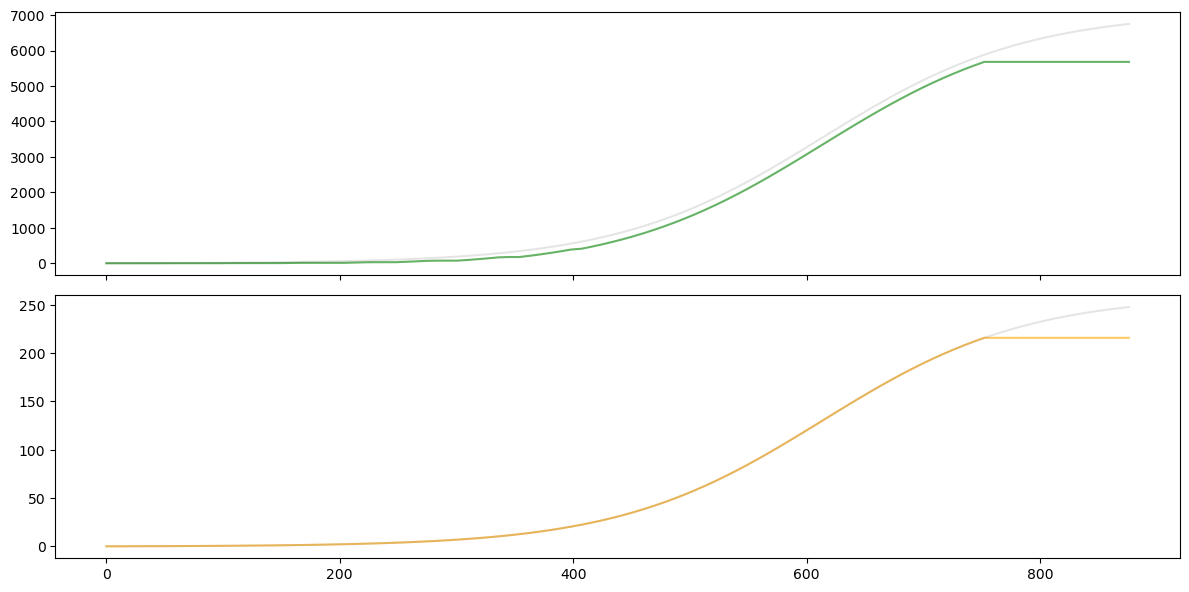

In [55]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)  # 1 row, 2 columns

rh = [sum([vl 
            for vid, vl in gp.properties()["visible_length"].items() 
            if gp.node(vid).label.startswith("Stem")]) 
            for gp in growing_rice.values()]
rla = [sum([vl 
            for vid, vl in gp.properties()["visible_leaf_area"].items()])
            for gp in growing_rice.values()]

axes[0].plot(tt, rla,  color="green", alpha=0.6)
axes[0].plot(tt, la, color="black", alpha=0.1)

axes[1].plot(tt, rh, color="orange", alpha=0.6)
axes[1].plot(tt, h, color="black", alpha=0.1)

plt.tight_layout()

# Show the plot
plt.show()